<a href="https://colab.research.google.com/github/caramos84/IBM-AI-Engineering-Course/blob/main/LinearRegression_Sample03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regresión lineal múltiple: predecir nota final con varias variables

En este ejercicio vamos a construir un modelo de **regresión lineal múltiple**.

A diferencia de la regresión lineal simple, donde usamos una sola variable de entrada, aquí utilizaremos varias variables para predecir la **nota final** de un estudiante.

Las variables de entrada serán:

- **Horas_Estudio**
- **Horas_Sueno**
- **Asistencia**

La variable objetivo será:

- **Nota_Final**

La idea es seguir una estructura similar al ejercicio anterior:

1. Importar librerías
2. Crear un dataset sencillo
3. Explorar los datos
4. Visualizar relaciones entre variables
5. Definir X e y
6. Dividir datos en entrenamiento y prueba
7. Entrenar el modelo
8. Ver coeficientes e interpretar el hiperplano
9. Evaluar el modelo
10. Hacer una interpretación final

In [1]:
# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Crear un dataset simple
data = {
    "Horas_Estudio": [2, 3, 4, 5, 6, 7, 8, 4, 6, 9, 10, 5],
    "Horas_Sueno":   [8, 7, 6, 7, 8, 6, 7, 5, 8, 6, 7, 6],
    "Asistencia":    [80, 85, 78, 90, 88, 92, 95, 75, 89, 96, 98, 84],
    "Nota_Final":    [60, 65, 67, 74, 78, 82, 86, 64, 79, 90, 94, 72]
}

df = pd.DataFrame(data)

# Ver las primeras filas
df.head()

,Horas_Estudio,Horas_Sueno,Asistencia,Nota_Final
0,2,8,80,60
1,3,7,85,65
2,4,6,78,67
3,5,7,90,74
4,6,8,88,78


## Exploración básica del dataset

Antes de entrenar el modelo, vamos a inspeccionar el conjunto de datos.

Esto nos ayuda a:

- ver ejemplos reales del dataset
- conocer estadísticas básicas
- entender cuántas filas y columnas tenemos

Aunque el dataset es pequeño y está limpio, este paso es importante porque en problemas reales permite detectar errores, valores extraños o inconsistencias antes de entrenar el modelo.

In [3]:
# Ver algunas filas aleatorias
df.sample(5)

,Horas_Estudio,Horas_Sueno,Asistencia,Nota_Final
1,3,7,85,65
11,5,6,84,72
4,6,8,88,78
10,10,7,98,94
8,6,8,89,79


In [4]:
# Ver algunas filas aleatorias
df.sample(5)

,Horas_Estudio,Horas_Sueno,Asistencia,Nota_Final
9,9,6,96,90
0,2,8,80,60
6,8,7,95,86
4,6,8,88,78
11,5,6,84,72


## Visualización de las variables

Ahora vamos a explorar visualmente el dataset.

Usaremos dos tipos de gráficos:

- **Histogramas**: para ver la distribución de cada variable
- **Gráficos de dispersión (scatter plots)**: para observar cómo se relaciona cada variable de entrada con la nota final

Como estamos en una regresión lineal múltiple, no podemos visualizar el hiperplano completo fácilmente, pero sí podemos inspeccionar la relación de cada variable por separado con la variable objetivo.

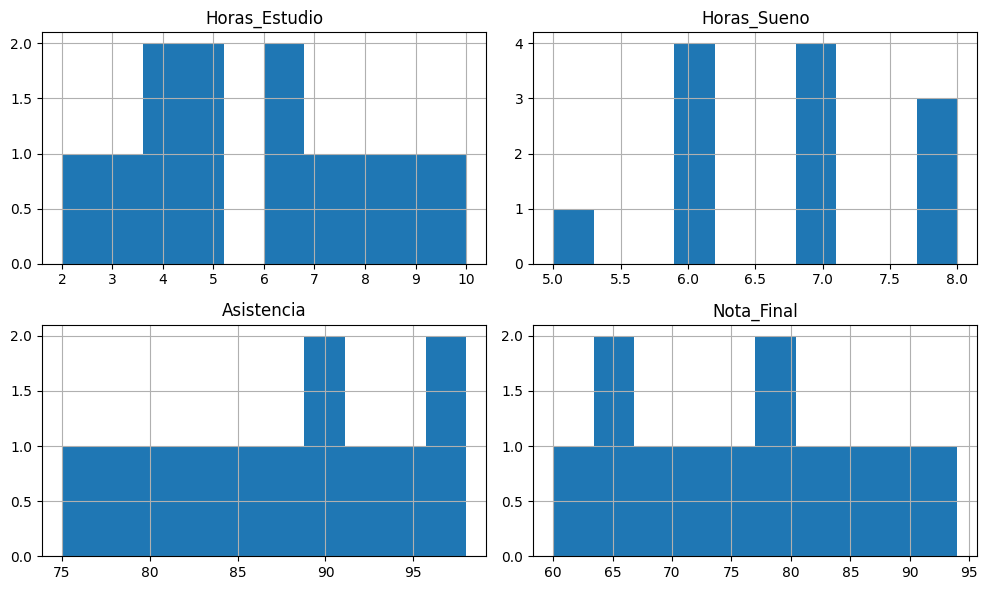

In [5]:
# Histogramas de todas las variables
df.hist(figsize=(10, 6))
plt.tight_layout()
plt.show()

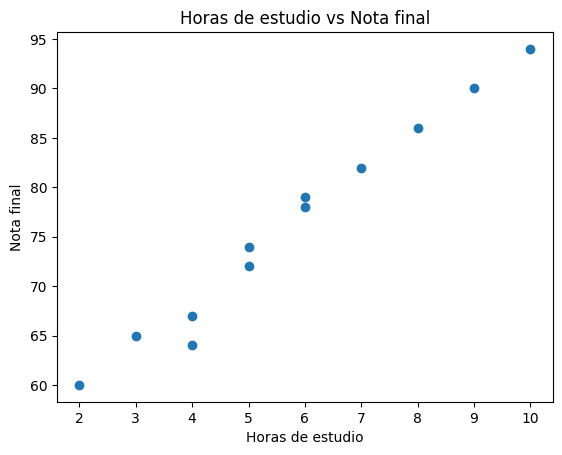

In [6]:
# Relación entre Horas_Estudio y Nota_Final
plt.scatter(df["Horas_Estudio"], df["Nota_Final"])
plt.xlabel("Horas de estudio")
plt.ylabel("Nota final")
plt.title("Horas de estudio vs Nota final")
plt.show()

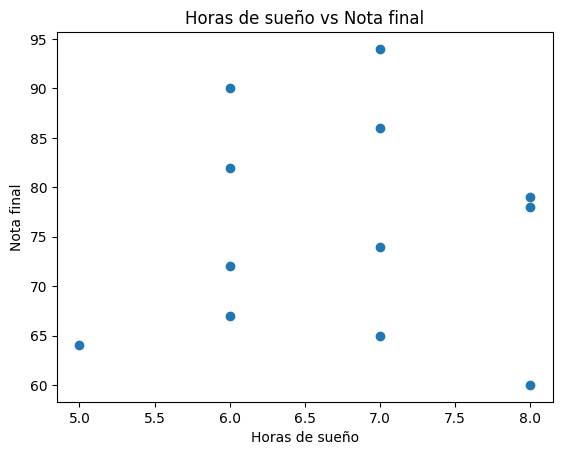

In [7]:
# Relación entre Horas_Sueno y Nota_Final
plt.scatter(df["Horas_Sueno"], df["Nota_Final"])
plt.xlabel("Horas de sueño")
plt.ylabel("Nota final")
plt.title("Horas de sueño vs Nota final")
plt.show()

## Definir variables de entrada (X) y variable objetivo (y)

En regresión lineal múltiple, la variable de entrada **X** ya no es una sola columna, sino un conjunto de varias variables predictoras.

En este ejercicio usaremos como variables de entrada:

- **Horas_Estudio**
- **Horas_Sueno**
- **Asistencia**

La variable objetivo será:

- **Nota_Final**

Esto significa que el modelo intentará predecir la nota final combinando la información de varias variables al mismo tiempo.

In [10]:
# Definir variables de entrada (X) y variable objetivo (y)
X = df[["Horas_Estudio", "Horas_Sueno", "Asistencia"]]
y = df["Nota_Final"]

print("X:")
print(X.head())

print("\ny:")
print(y.head())

X:
   Horas_Estudio  Horas_Sueno  Asistencia
0              2            8          80
1              3            7          85
2              4            6          78
3              5            7          90
4              6            8          88

y:
0    60
1    65
2    67
3    74
4    78
Name: Nota_Final, dtype: int64


## Dividir los datos en entrenamiento y prueba

Antes de entrenar el modelo, vamos a dividir el dataset en dos partes:

- **Conjunto de entrenamiento**: se usa para que el modelo aprenda la relación entre las variables de entrada y la nota final.
- **Conjunto de prueba**: se usa para evaluar qué tan bien funciona el modelo con datos que no vio durante el entrenamiento.

Usaremos:

- **80%** de los datos para entrenamiento
- **20%** de los datos para prueba

Esta división es importante porque ayuda a detectar si el modelo generaliza bien o si está demasiado ajustado a los datos de entrenamiento.

In [11]:
# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:")
print(X_train)

print("\nX_test:")
print(X_test)

print("\ny_train:")
print(y_train)

print("\ny_test:")
print(y_test)

X_train:
    Horas_Estudio  Horas_Sueno  Asistencia
8               6            8          89
5               7            6          92
2               4            6          78
1               3            7          85
11              5            6          84
4               6            8          88
7               4            5          75
3               5            7          90
6               8            7          95

X_test:
    Horas_Estudio  Horas_Sueno  Asistencia
10             10            7          98
9               9            6          96
0               2            8          80

y_train:
8     79
5     82
2     67
1     65
11    72
4     78
7     64
3     74
6     86
Name: Nota_Final, dtype: int64

y_test:
10    94
9     90
0     60
Name: Nota_Final, dtype: int64


## Crear y entrenar el modelo de regresión lineal múltiple

Ahora vamos a crear un modelo de **regresión lineal múltiple** usando `scikit-learn`.

El modelo aprenderá una ecuación de la forma:

**Nota_Final = b0 + b1(Horas_Estudio) + b2(Horas_Sueno) + b3(Asistencia)**

Aquí:

- **b0** es el intercepto
- **b1, b2, b3** son los coeficientes de cada variable

Durante el entrenamiento, el modelo ajusta estos coeficientes para minimizar los errores cuadrados.  
Esa es la lógica de **Least Squares**.

In [12]:
# Crear el modelo
regressor = linear_model.LinearRegression()

# Entrenar el modelo
regressor.fit(X_train, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


## Ver los coeficientes e interpretar el modelo

Una vez entrenado el modelo, podemos inspeccionar los coeficientes aprendidos.

En regresión lineal múltiple, el modelo tiene la forma:

**Nota_Final = b0 + b1(Horas_Estudio) + b2(Horas_Sueno) + b3(Asistencia)**

donde:

- **b0** es el intercepto
- **b1** es el efecto de Horas_Estudio
- **b2** es el efecto de Horas_Sueno
- **b3** es el efecto de Asistencia

Cada coeficiente indica cuánto cambia la nota final cuando esa variable aumenta en una unidad, manteniendo las demás constantes.

Eso último es muy importante: en regresión múltiple, cada coeficiente se interpreta **controlando por las otras variables**.

In [13]:
# Ver el intercepto
print("Intercepto:", regressor.intercept_)

# Ver los coeficientes
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": regressor.coef_
})

coeficientes

Intercepto: 25.645476772616078


,Variable,Coeficiente
0,Horas_Estudio,3.767319
1,Horas_Sueno,0.872453
2,Asistencia,0.261614


In [14]:
# Mostrar la ecuación del modelo de forma legible
b0 = regressor.intercept_
b1, b2, b3 = regressor.coef_

print("Ecuación del modelo:")
print(f"Nota_Final = {b0:.2f} + ({b1:.2f} * Horas_Estudio) + ({b2:.2f} * Horas_Sueno) + ({b3:.2f} * Asistencia)")

Ecuación del modelo:
Nota_Final = 25.65 + (3.77 * Horas_Estudio) + (0.87 * Horas_Sueno) + (0.26 * Asistencia)


## Hacer predicciones y evaluar el modelo

Ahora vamos a usar el modelo entrenado para predecir la nota final en el conjunto de prueba.

Después compararemos los valores reales con los valores predichos y calcularemos varias métricas de evaluación:

- **MAE (Mean Absolute Error)**: error absoluto promedio
- **MSE (Mean Squared Error)**: error cuadrático promedio
- **RMSE (Root Mean Squared Error)**: raíz del error cuadrático promedio
- **R²**: proporción de la variación explicada por el modelo

Estas métricas nos ayudan a entender qué tan bien generaliza el modelo a datos nuevos.

In [15]:
# Hacer predicciones sobre el conjunto de prueba
y_pred = regressor.predict(X_test)

print("Valores reales:")
print(y_test.values)

print("\nValores predichos:")
print(y_pred)

Valores reales:
[94 90 60]

Valores predichos:
[95.06397718 89.900978   61.08883456]


In [16]:
# Calcular métricas de evaluación
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.2f}")

MAE:  0.75
MSE:  0.78
RMSE: 0.88
R²:   1.00


In [18]:
# Comparar resultados en una tabla
results = X_test.copy()
results["Nota_Real"] = y_test.values
results["Nota_Predicha"] = y_pred

results

,Horas_Estudio,Horas_Sueno,Asistencia,Nota_Real,Nota_Predicha
10,10,7,98,94,95.063977
9,9,6,96,90,89.900978
0,2,8,80,60,61.088835


## Interpretación final del modelo

Ya entrenamos y evaluamos un modelo de regresión lineal múltiple.

Ahora vamos a hacer una interpretación final de los resultados, conectando:

- la ecuación del modelo
- el significado de los coeficientes
- el papel del intercepto
- el error medido con MSE
- la idea del hiperplano

Esto nos ayuda a cerrar el ejercicio entendiendo no solo cómo se ejecuta el modelo, sino también qué significa.

In [19]:
# Guardar coeficientes en variables para interpretación
b0 = regressor.intercept_
b1, b2, b3 = regressor.coef_

print("Ecuación final del modelo:")
print(f"Nota_Final = {b0:.2f} + ({b1:.2f} * Horas_Estudio) + ({b2:.2f} * Horas_Sueno) + ({b3:.2f} * Asistencia)")

Ecuación final del modelo:
Nota_Final = 25.65 + (3.77 * Horas_Estudio) + (0.87 * Horas_Sueno) + (0.26 * Asistencia)


In [20]:
print("\nInterpretación del modelo:")
print(f"- Intercepto: {b0:.2f}")
print("  Es el valor base estimado de la nota cuando todas las variables valen 0.")

print(f"- Horas_Estudio: {b1:.2f}")
print("  Indica cuánto cambia la nota por cada hora adicional de estudio, manteniendo constantes las demás variables.")

print(f"- Horas_Sueno: {b2:.2f}")
print("  Indica cuánto cambia la nota por cada hora adicional de sueño, manteniendo constantes las demás variables.")

print(f"- Asistencia: {b3:.2f}")
print("  Indica cuánto cambia la nota por cada unidad adicional de asistencia, manteniendo constantes las demás variables.")

print(f"\n- MSE: {mse:.2f}")
print("  Resume el tamaño promedio de los errores al cuadrado.")

print(f"- R²: {r2:.2f}")
print("  Indica qué proporción de la variación de la nota final es explicada por el modelo.")


Interpretación del modelo:
- Intercepto: 25.65
  Es el valor base estimado de la nota cuando todas las variables valen 0.
- Horas_Estudio: 3.77
  Indica cuánto cambia la nota por cada hora adicional de estudio, manteniendo constantes las demás variables.
- Horas_Sueno: 0.87
  Indica cuánto cambia la nota por cada hora adicional de sueño, manteniendo constantes las demás variables.
- Asistencia: 0.26
  Indica cuánto cambia la nota por cada unidad adicional de asistencia, manteniendo constantes las demás variables.

- MSE: 0.78
  Resume el tamaño promedio de los errores al cuadrado.
- R²: 1.00
  Indica qué proporción de la variación de la nota final es explicada por el modelo.


In [21]:
print("\nConclusión:")
print("Este modelo de regresión lineal múltiple usa varias variables para predecir una salida continua.")
print("Geométricamente, el modelo ajusta un hiperplano en un espacio de varias dimensiones.")
print("Los coeficientes indican el efecto parcial de cada variable sobre la nota final.")
print("El modelo fue ajustado minimizando errores cuadrados, según la lógica de Least Squares.")


Conclusión:
Este modelo de regresión lineal múltiple usa varias variables para predecir una salida continua.
Geométricamente, el modelo ajusta un hiperplano en un espacio de varias dimensiones.
Los coeficientes indican el efecto parcial de cada variable sobre la nota final.
El modelo fue ajustado minimizando errores cuadrados, según la lógica de Least Squares.


## Escenario what if: estimar cuántas horas de estudio se necesitan para obtener 100

En una regresión lineal múltiple, también podemos usar el modelo para plantear escenarios hipotéticos.

Por ejemplo, podemos preguntarnos:

**Si un estudiante duerme 7 horas y tiene 95 de asistencia, ¿cuántas horas de estudio necesitaría para alcanzar una nota de 100?**

A diferencia de la regresión lineal simple, aquí no existe una única respuesta automática, porque hay varias variables de entrada.

Por eso, para despejar una variable, necesitamos fijar valores para las demás.

In [22]:
# Escenario hipotético
nota_objetivo = 100
horas_sueno_fijas = 7
asistencia_fija = 95

# Despejar Horas_Estudio de la ecuación del modelo
horas_estudio_necesarias = (
    nota_objetivo - b0 - (b2 * horas_sueno_fijas) - (b3 * asistencia_fija)
) / b1

print("Escenario what if:")
print(f"- Nota objetivo: {nota_objetivo}")
print(f"- Horas de sueño fijas: {horas_sueno_fijas}")
print(f"- Asistencia fija: {asistencia_fija}")
print(f"\nHoras de estudio estimadas para alcanzar {nota_objetivo}: {horas_estudio_necesarias:.2f}")

Escenario what if:
- Nota objetivo: 100
- Horas de sueño fijas: 7
- Asistencia fija: 95

Horas de estudio estimadas para alcanzar 100: 11.52


In [23]:
print("\nInterpretación:")
print("Este valor representa una estimación basada en el modelo de regresión lineal múltiple.")
print("No es una garantía exacta, sino una proyección de la tendencia aprendida por el modelo.")
print("Si cambian las horas de sueño o la asistencia, también cambiaría la cantidad de horas de estudio necesarias.")


Interpretación:
Este valor representa una estimación basada en el modelo de regresión lineal múltiple.
No es una garantía exacta, sino una proyección de la tendencia aprendida por el modelo.
Si cambian las horas de sueño o la asistencia, también cambiaría la cantidad de horas de estudio necesarias.


## Conclusión general

En este ejercicio construimos un modelo de **regresión lineal múltiple** para predecir la **nota final** de un estudiante a partir de varias variables:

- horas de estudio
- horas de sueño
- asistencia

A lo largo del proceso:

1. exploramos el dataset
2. visualizamos relaciones entre variables
3. definimos variables de entrada y salida
4. dividimos los datos en entrenamiento y prueba
5. entrenamos un modelo de regresión lineal múltiple
6. interpretamos coeficientes e intercepto
7. evaluamos el modelo con métricas como **MSE** y **R²**
8. usamos el modelo para plantear un escenario **what if**

Este ejercicio permite entender varias ideas clave de machine learning:

- un modelo aprende patrones a partir de datos
- los coeficientes representan el efecto parcial de cada variable
- el intercepto funciona como valor base del modelo
- el error se mide con métricas como MAE, MSE y RMSE
- en múltiples dimensiones, el modelo ajusta un **hiperplano**
- el modelo puede usarse no solo para predecir, sino también para explorar escenarios hipotéticos

La regresión lineal múltiple es una herramienta simple, pero muy importante, porque introduce conceptos fundamentales de **predicción**, **optimización**, **generalización** e **interpretación de modelos**.

In [24]:
print("Notebook finalizado correctamente.")
print("Tema trabajado: Regresión lineal múltiple")
print("Conceptos clave:")
print("- Variables predictoras múltiples")
print("- Hiperplano")
print("- Least Squares")
print("- MSE, RMSE y R²")
print("- Interpretación de coeficientes")
print("- Escenarios what if")

Notebook finalizado correctamente.
Tema trabajado: Regresión lineal múltiple
Conceptos clave:
- Variables predictoras múltiples
- Hiperplano
- Least Squares
- MSE, RMSE y R²
- Interpretación de coeficientes
- Escenarios what if
